In [1]:
import numpy as np
import pandas as pd
import emoji
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import glob
import matplotlib.dates as mdates
import matplotlib.cm as cm


In [4]:
df1 = pd.read_csv('../data/articles/AI_articles2025-2026.csv')
df1.head()

,Unnamed: 0,url,error,title,text,top_image,images
0,0,https://www.theguardian.com/technology/2025/de...,NaN,"Elon Musk, AI and the antichrist: the biggest ...","Hello, and welcome to TechScape. I’m your host...",https://i.guim.co.uk/img/media/deb2b33ba7ff621...,['https://i.guim.co.uk/img/media/deb2b33ba7ff6...
1,1,https://theconversation.com/how-can-canada-bec...,NaN,How can Canada become a global AI powerhouse? ...,Artificial intelligence is everywhere. In fact...,https://images.theconversation.com/files/70923...,"['data:image/gif;base64,R0lGODlhAQABAAD/ACwAAA..."
2,2,https://www.cnbc.com/2025/12/23/ai-cost-effici...,NaN,The next AI pivot will be toward efficiency an...,"Kelly, who was also general counsel at Faceboo...",https://image.cnbcfm.com/api/v1/image/10817571...,['https://image.cnbcfm.com/api/v1/image/108213...
3,3,https://www.businessinsider.com/how-ai-transfo...,NaN,How AI Is Transforming the Workplace Faster Th...,AI is changing everything from what type of wo...,https://i.insider.com/694ae36a832e0ef1ead6bfbe...,['https://www.businessinsider.com/public/asset...
4,4,https://www.sandiegouniontribune.com/2025/12/2...,NaN,UC San Diego eyes campuswide AI coordinating s...,As institutions across the world establish app...,https://www.sandiegouniontribune.com/wp-conten...,['https://www.sandiegouniontribune.com/wp-cont...


In [6]:
df1.shape

(36320, 7)

In [5]:
df2 = pd.read_csv('../data/articles/AI_articles_metadata.csv')
df2.head()

,Unnamed: 0,id,indexed_date,language,media_name,media_url,publish_date,title,url
0,0,19d73b7cd0a23f961ea3aae6d1554c62b004aac1a4a6c7...,2025-12-24 05:22:29.307373+00:00,en,sandiegouniontribune.com,sandiegouniontribune.com,2025-12-23,UC San Diego eyes campuswide AI coordinating s...,https://www.sandiegouniontribune.com/2025/12/2...
1,3,5dc81d658b56b2424da775f9d2496810172b4e7e907305...,2025-12-24 03:21:38.495827+00:00,en,theweek.com,theweek.com,2025-12-23,Trump vs. states: Who gets to regulate AI?,https://theweek.com/politics/trump-states-regu...
2,6,8424d86c8fb3e91c1ba6ac73b2a9c92fae17bf36871802...,2025-12-24 00:29:59.301749+00:00,en,benzinga.com,benzinga.com,2025-12-23,AI Pioneer Yoshua Bengio Reveals He Misleads C...,https://www.benzinga.com/markets/tech/25/12/49...
3,8,ee34202162eff5335539b80f463a1b20b5f73173155656...,2025-12-24 00:22:34.618199+00:00,en,benzinga.com,benzinga.com,2025-12-23,From Discoverative AI to the Entropy of Tolera...,https://www.benzinga.com/pressreleases/25/12/n...
4,11,df68b6f39f396d32a2f81a00f381bc30eeb07f72186d82...,2025-12-24 00:19:46.702100+00:00,en,ign.com,ign.com,2025-12-23,"Eddy Burback Made The First Great Horror ""Movi...",https://www.ign.com/videos/eddy-burback-made-t...


In [7]:
df2.shape

(61362, 9)

In [8]:
df = df1.merge(df2[['url','id', 'indexed_date','media_name', 'media_url','publish_date']], on='url', how='left')

In [9]:
df.shape

(36320, 12)

In [10]:
df.head()

,Unnamed: 0,url,error,title,text,top_image,images,id,indexed_date,media_name,media_url,publish_date
0,0,https://www.theguardian.com/technology/2025/de...,NaN,"Elon Musk, AI and the antichrist: the biggest ...","Hello, and welcome to TechScape. I’m your host...",https://i.guim.co.uk/img/media/deb2b33ba7ff621...,['https://i.guim.co.uk/img/media/deb2b33ba7ff6...,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,2025-12-23 20:26:44.681968+00:00,theguardian.com,theguardian.com,2025-12-23
1,1,https://theconversation.com/how-can-canada-bec...,NaN,How can Canada become a global AI powerhouse? ...,Artificial intelligence is everywhere. In fact...,https://images.theconversation.com/files/70923...,"['data:image/gif;base64,R0lGODlhAQABAAD/ACwAAA...",d219ab84d8d98f17fd7d5abb20cee560e007ae14c0de6c...,2025-12-23 22:32:17.716034+00:00,theconversation.com,theconversation.com,2025-12-23
2,2,https://www.cnbc.com/2025/12/23/ai-cost-effici...,NaN,The next AI pivot will be toward efficiency an...,"Kelly, who was also general counsel at Faceboo...",https://image.cnbcfm.com/api/v1/image/10817571...,['https://image.cnbcfm.com/api/v1/image/108213...,883df3997e09f2234edf2f2877d7c149d627976763be5d...,2025-12-23 19:17:47.972258+00:00,cnbc.com,cnbc.com,2025-12-23
3,3,https://www.businessinsider.com/how-ai-transfo...,NaN,How AI Is Transforming the Workplace Faster Th...,AI is changing everything from what type of wo...,https://i.insider.com/694ae36a832e0ef1ead6bfbe...,['https://www.businessinsider.com/public/asset...,76a0a35549b802213cc653e25036aa5999fcd2e89d6ab3...,2025-12-23 20:22:34.590390+00:00,businessinsider.com,businessinsider.com,2025-12-23
4,4,https://www.sandiegouniontribune.com/2025/12/2...,NaN,UC San Diego eyes campuswide AI coordinating s...,As institutions across the world establish app...,https://www.sandiegouniontribune.com/wp-conten...,['https://www.sandiegouniontribune.com/wp-cont...,19d73b7cd0a23f961ea3aae6d1554c62b004aac1a4a6c7...,2025-12-24 05:22:29.307373+00:00,sandiegouniontribune.com,sandiegouniontribune.com,2025-12-23


In [11]:
df.to_csv('final_AI_articles.csv')

In [2]:
df = pd.read_csv('../data/articles/final_AI_articles.csv')

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,url,error,title,text,top_image,images,id,indexed_date,media_name,media_url,publish_date
0,0,0,https://www.theguardian.com/technology/2025/de...,NaN,"Elon Musk, AI and the antichrist: the biggest ...","Hello, and welcome to TechScape. I’m your host...",https://i.guim.co.uk/img/media/deb2b33ba7ff621...,['https://i.guim.co.uk/img/media/deb2b33ba7ff6...,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,2025-12-23 20:26:44.681968+00:00,theguardian.com,theguardian.com,2025-12-23
1,1,1,https://theconversation.com/how-can-canada-bec...,NaN,How can Canada become a global AI powerhouse? ...,Artificial intelligence is everywhere. In fact...,https://images.theconversation.com/files/70923...,"['data:image/gif;base64,R0lGODlhAQABAAD/ACwAAA...",d219ab84d8d98f17fd7d5abb20cee560e007ae14c0de6c...,2025-12-23 22:32:17.716034+00:00,theconversation.com,theconversation.com,2025-12-23
2,2,2,https://www.cnbc.com/2025/12/23/ai-cost-effici...,NaN,The next AI pivot will be toward efficiency an...,"Kelly, who was also general counsel at Faceboo...",https://image.cnbcfm.com/api/v1/image/10817571...,['https://image.cnbcfm.com/api/v1/image/108213...,883df3997e09f2234edf2f2877d7c149d627976763be5d...,2025-12-23 19:17:47.972258+00:00,cnbc.com,cnbc.com,2025-12-23
3,3,3,https://www.businessinsider.com/how-ai-transfo...,NaN,How AI Is Transforming the Workplace Faster Th...,AI is changing everything from what type of wo...,https://i.insider.com/694ae36a832e0ef1ead6bfbe...,['https://www.businessinsider.com/public/asset...,76a0a35549b802213cc653e25036aa5999fcd2e89d6ab3...,2025-12-23 20:22:34.590390+00:00,businessinsider.com,businessinsider.com,2025-12-23
4,4,4,https://www.sandiegouniontribune.com/2025/12/2...,NaN,UC San Diego eyes campuswide AI coordinating s...,As institutions across the world establish app...,https://www.sandiegouniontribune.com/wp-conten...,['https://www.sandiegouniontribune.com/wp-cont...,19d73b7cd0a23f961ea3aae6d1554c62b004aac1a4a6c7...,2025-12-24 05:22:29.307373+00:00,sandiegouniontribune.com,sandiegouniontribune.com,2025-12-23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36320 entries, 0 to 36319
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  36320 non-null  int64  
 1   Unnamed: 0    36320 non-null  int64  
 2   url           36320 non-null  object 
 3   error         0 non-null      float64
 4   title         36154 non-null  object 
 5   text          36149 non-null  object 
 6   top_image     36154 non-null  object 
 7   images        36320 non-null  object 
 8   id            36320 non-null  object 
 9   indexed_date  36320 non-null  object 
 10  media_name    36320 non-null  object 
 11  media_url     36320 non-null  object 
 12  publish_date  36320 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.6+ MB


In [7]:
df['id'].nunique()

36320

In [12]:
media_count = df['media_name'].value_counts(ascending=False)
media_count.shape

(191,)

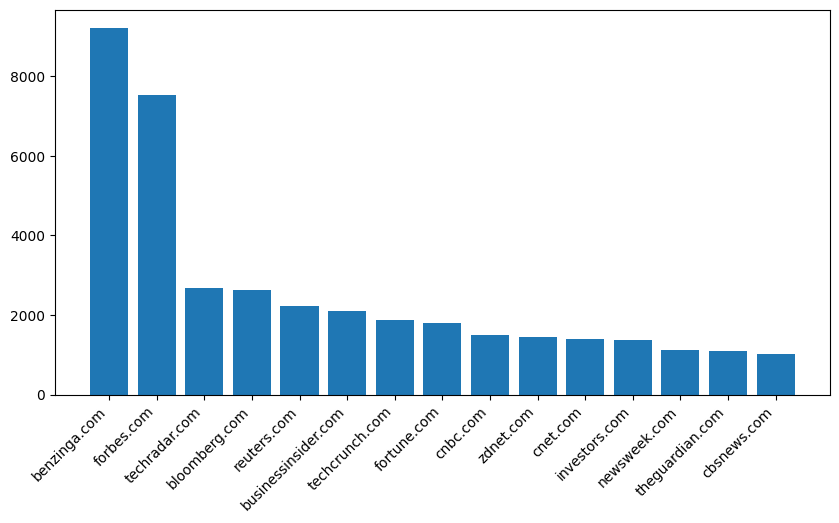

In [15]:
top_15 = media_count[:15]
plt.figure(figsize=(10,5))
plt.bar(top_15.index, top_15)
plt.xticks(rotation=45, ha='right')
plt.show()

/var/folders/rs/w8c5y18s1xv84854pv0h3vxc0000gn/T/ipykernel_4445/801529990.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts = df.groupby(df['indexed_date'].dt.to_period('M')).size()


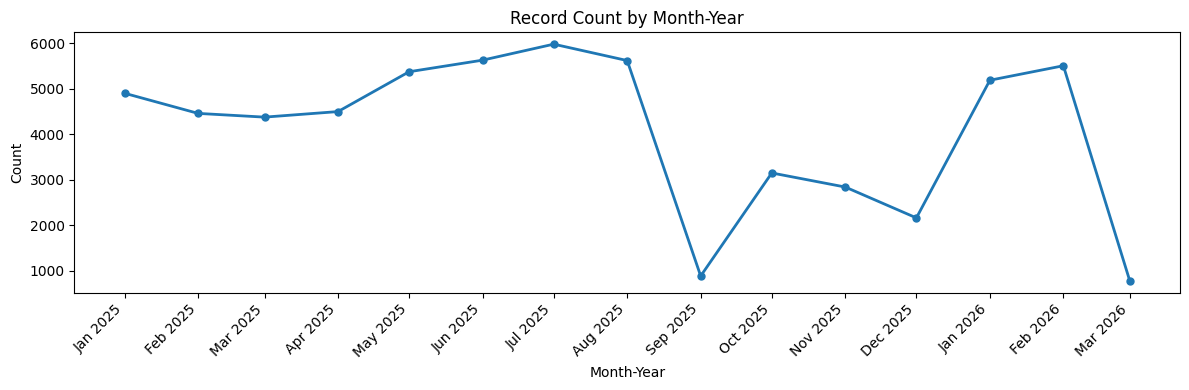

In [21]:
monthly_counts = df.groupby(df['indexed_date'].dt.to_period('M')).size()
monthly_counts.index = monthly_counts.index.to_timestamp()  

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_counts.index, monthly_counts.values, marker='o', linewidth=2, markersize=5)

# Format x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

ax.set_title('Record Count by Month-Year')
ax.set_xlabel('Month-Year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [22]:
df["month_year"] = df["indexed_date"].dt.strftime("%B %Y")

In [37]:
top_15_trend = df[df['media_name'].isin(top_15.index)].groupby(['media_name', 'month_year']).size().reset_index(name='count')
top_15_trend

,media_name,month_year,count
0,benzinga.com,April 2025,768
1,benzinga.com,August 2025,901
2,benzinga.com,December 2025,194
3,benzinga.com,February 2025,723
4,benzinga.com,February 2026,939
...,...,...,...
220,zdnet.com,March 2026,9
221,zdnet.com,May 2025,148
222,zdnet.com,November 2025,60
223,zdnet.com,October 2025,81


In [43]:
top_15_trend['date_order'] = pd.to_datetime(top_15_trend['month_year'], format='%B %Y')
top_15_trend = top_15_trend.sort_values('date_order')
sorted_months = top_15_trend['date_order'].sort_values().unique()
sorted_labels = pd.to_datetime(sorted_months).strftime('%B %Y')

[]

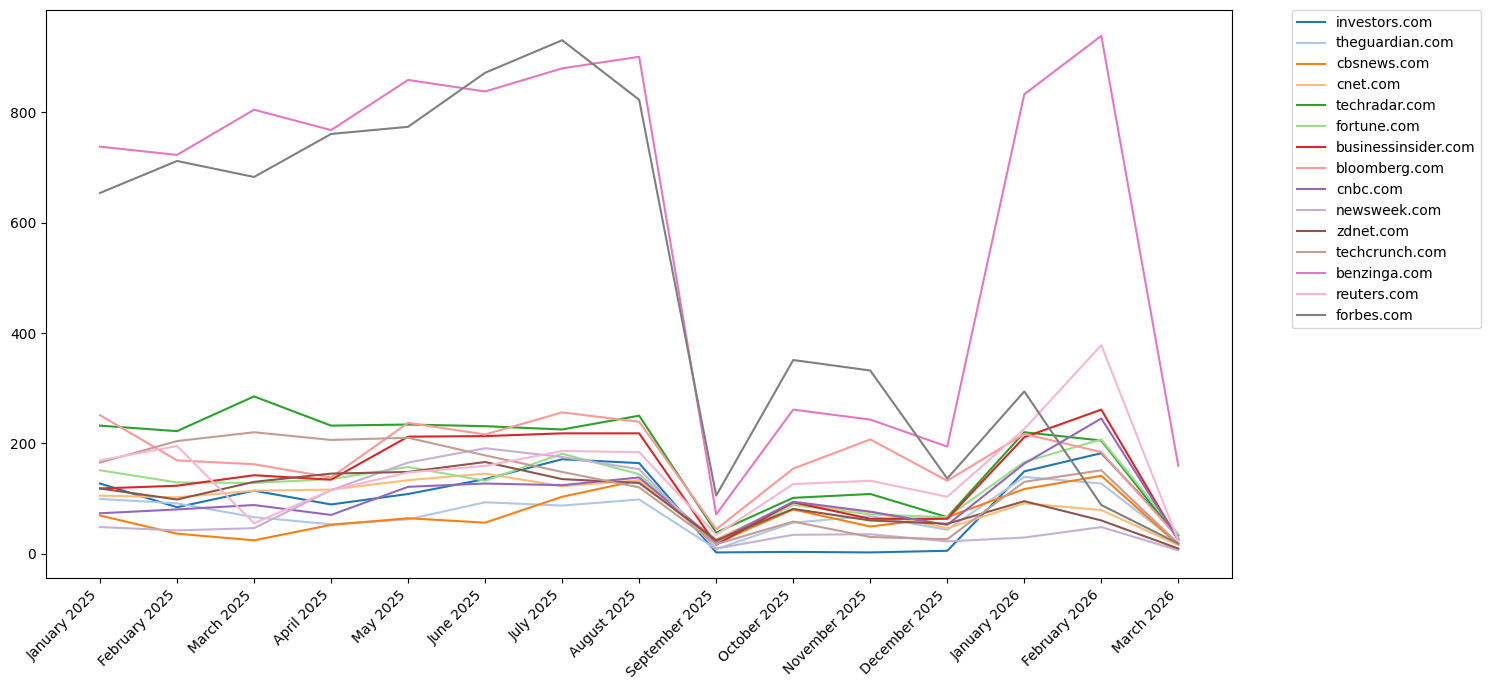

In [48]:
colors = cm.tab20.colors[:15]
plt.figure(figsize=(15,7))
for i, media_name in enumerate(top_15_trend['media_name'].unique()):
    plt.plot(top_15_trend[top_15_trend['media_name']== media_name]['month_year'], 
             top_15_trend[top_15_trend['media_name']== media_name]['count'], label=media_name, color=colors[i])
plt.xticks(ticks=sorted_labels, labels=sorted_labels, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.plot()

In [5]:
image_folder = Path('../data/processed/images_filtered')
images_downloaded = pd.DataFrame({
    "filename": [f.name for f in image_folder.iterdir() if f.is_file()]
})

In [6]:
images_downloaded.shape

(43597, 1)

In [7]:
images_downloaded.head()

,filename
0,article_6c2fc7e055d144b8e3cc1f0e8f739c461a30b9...
1,article_ad0393a55405e47ce1fd2c946dbe982f976edc...
2,article_2251a706870b0b0076d1309e257fea1250f36c...
3,article_127584088a09a90ce8c877a39d50c57dfb2ab8...
4,article_0971e6b2ec25915cba51a74e5dd2e05dc12802...


In [9]:
def get_id(filename):
    pattern = re.compile(r"^article_(.+?)_img_\d+\.")
    match = pattern.match(filename)
    article_id = match.group(1) if match else None
    return article_id

In [10]:
images_downloaded['id'] = images_downloaded['filename'].apply(get_id)

In [11]:
images_downloaded.info()

<class 'pandas.DataFrame'>
RangeIndex: 43597 entries, 0 to 43596
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  43597 non-null  str  
 1   id        43597 non-null  str  
dtypes: str(2)
memory usage: 681.3 KB


In [13]:
images_downloaded.head()

,filename,id
0,article_6c2fc7e055d144b8e3cc1f0e8f739c461a30b9...,6c2fc7e055d144b8e3cc1f0e8f739c461a30b915aa5fd3...
1,article_ad0393a55405e47ce1fd2c946dbe982f976edc...,ad0393a55405e47ce1fd2c946dbe982f976edcf3a5b54c...
2,article_2251a706870b0b0076d1309e257fea1250f36c...,2251a706870b0b0076d1309e257fea1250f36c640be9be...
3,article_127584088a09a90ce8c877a39d50c57dfb2ab8...,127584088a09a90ce8c877a39d50c57dfb2ab8d93f66f1...
4,article_0971e6b2ec25915cba51a74e5dd2e05dc12802...,0971e6b2ec25915cba51a74e5dd2e05dc1280286a9342c...


In [14]:
images_downloaded['id'].nunique()

3533

In [15]:
df['is_downloaded'] = df['id'].isin(images_downloaded['id'])

In [16]:
df['is_downloaded'].sum()

np.int64(3533)

In [17]:
df.head()

,Unnamed: 0.1,Unnamed: 0,url,error,title,text,top_image,images,id,indexed_date,media_name,media_url,publish_date,is_downloaded
0,0,0,https://www.theguardian.com/technology/2025/de...,NaN,"Elon Musk, AI and the antichrist: the biggest ...","Hello, and welcome to TechScape. I’m your host...",https://i.guim.co.uk/img/media/deb2b33ba7ff621...,['https://i.guim.co.uk/img/media/deb2b33ba7ff6...,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,2025-12-23 20:26:44.681968+00:00,theguardian.com,theguardian.com,2025-12-23,False
1,1,1,https://theconversation.com/how-can-canada-bec...,NaN,How can Canada become a global AI powerhouse? ...,Artificial intelligence is everywhere. In fact...,https://images.theconversation.com/files/70923...,"['data:image/gif;base64,R0lGODlhAQABAAD/ACwAAA...",d219ab84d8d98f17fd7d5abb20cee560e007ae14c0de6c...,2025-12-23 22:32:17.716034+00:00,theconversation.com,theconversation.com,2025-12-23,False
2,2,2,https://www.cnbc.com/2025/12/23/ai-cost-effici...,NaN,The next AI pivot will be toward efficiency an...,"Kelly, who was also general counsel at Faceboo...",https://image.cnbcfm.com/api/v1/image/10817571...,['https://image.cnbcfm.com/api/v1/image/108213...,883df3997e09f2234edf2f2877d7c149d627976763be5d...,2025-12-23 19:17:47.972258+00:00,cnbc.com,cnbc.com,2025-12-23,False
3,3,3,https://www.businessinsider.com/how-ai-transfo...,NaN,How AI Is Transforming the Workplace Faster Th...,AI is changing everything from what type of wo...,https://i.insider.com/694ae36a832e0ef1ead6bfbe...,['https://www.businessinsider.com/public/asset...,76a0a35549b802213cc653e25036aa5999fcd2e89d6ab3...,2025-12-23 20:22:34.590390+00:00,businessinsider.com,businessinsider.com,2025-12-23,False
4,4,4,https://www.sandiegouniontribune.com/2025/12/2...,NaN,UC San Diego eyes campuswide AI coordinating s...,As institutions across the world establish app...,https://www.sandiegouniontribune.com/wp-conten...,['https://www.sandiegouniontribune.com/wp-cont...,19d73b7cd0a23f961ea3aae6d1554c62b004aac1a4a6c7...,2025-12-24 05:22:29.307373+00:00,sandiegouniontribune.com,sandiegouniontribune.com,2025-12-23,True


In [19]:
df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)

In [20]:
df.head()

,url,error,title,text,top_image,images,id,indexed_date,media_name,media_url,publish_date,is_downloaded
0,https://www.theguardian.com/technology/2025/de...,NaN,"Elon Musk, AI and the antichrist: the biggest ...","Hello, and welcome to TechScape. I’m your host...",https://i.guim.co.uk/img/media/deb2b33ba7ff621...,['https://i.guim.co.uk/img/media/deb2b33ba7ff6...,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,2025-12-23 20:26:44.681968+00:00,theguardian.com,theguardian.com,2025-12-23,False
1,https://theconversation.com/how-can-canada-bec...,NaN,How can Canada become a global AI powerhouse? ...,Artificial intelligence is everywhere. In fact...,https://images.theconversation.com/files/70923...,"['data:image/gif;base64,R0lGODlhAQABAAD/ACwAAA...",d219ab84d8d98f17fd7d5abb20cee560e007ae14c0de6c...,2025-12-23 22:32:17.716034+00:00,theconversation.com,theconversation.com,2025-12-23,False
2,https://www.cnbc.com/2025/12/23/ai-cost-effici...,NaN,The next AI pivot will be toward efficiency an...,"Kelly, who was also general counsel at Faceboo...",https://image.cnbcfm.com/api/v1/image/10817571...,['https://image.cnbcfm.com/api/v1/image/108213...,883df3997e09f2234edf2f2877d7c149d627976763be5d...,2025-12-23 19:17:47.972258+00:00,cnbc.com,cnbc.com,2025-12-23,False
3,https://www.businessinsider.com/how-ai-transfo...,NaN,How AI Is Transforming the Workplace Faster Th...,AI is changing everything from what type of wo...,https://i.insider.com/694ae36a832e0ef1ead6bfbe...,['https://www.businessinsider.com/public/asset...,76a0a35549b802213cc653e25036aa5999fcd2e89d6ab3...,2025-12-23 20:22:34.590390+00:00,businessinsider.com,businessinsider.com,2025-12-23,False
4,https://www.sandiegouniontribune.com/2025/12/2...,NaN,UC San Diego eyes campuswide AI coordinating s...,As institutions across the world establish app...,https://www.sandiegouniontribune.com/wp-conten...,['https://www.sandiegouniontribune.com/wp-cont...,19d73b7cd0a23f961ea3aae6d1554c62b004aac1a4a6c7...,2025-12-24 05:22:29.307373+00:00,sandiegouniontribune.com,sandiegouniontribune.com,2025-12-23,True


In [21]:
df_remaining = df[df['is_downloaded'] == False]
df_remaining.shape

(32787, 12)

In [22]:
df_remaining.to_csv('Remaining1.csv')